# 06: Contextual Policy Learning

This notebook is the advanced modeling notebook for  **Off-Policy Evaluation of Recommendation Systems**.

The earlier notebooks evaluated simple policies that assigned the same item probabilities for every user/context. That was useful for learning IPS, SNIPS, direct method, and doubly robust OPE, but real recommendation systems are contextual. A production recommendation policy should change its item choices based on user features, time, position, and item-user affinity signals.

This notebook asks:

> Can we learn a context-aware recommendation policy from logged data, then evaluate it offline with OPE?

We train reward models, score every held-out context against every candidate item, convert those scores into contextual policies, and evaluate those policies with IPS, SNIPS, direct method, and doubly robust estimation.


<!-- dataset-experiment-context -->
## Dataset and Experiment Context

This project uses the Open Bandit Dataset from a fashion e-commerce recommendation setting. Each row is a logged recommendation event with context features, the item action chosen by the behavior policy, a binary click reward, and the behavior-policy propensity for the chosen action.

The main analysis uses the `random/men` campaign because randomized logging gives broad action support and known propensities. Open Bandit also contains adaptive Bernoulli Thompson Sampling logs, but random logging is the cleanest starting point for off-policy evaluation.

The offline experiment asks which candidate recommendation policy deserves online validation. IPS, SNIPS, direct method, doubly robust estimates, effective sample size, clipping sensitivity, and reward-model diagnostics are treated as launch-readiness evidence for later online testing.

**Role of this notebook.** This notebook trains context-aware reward models and evaluates learned policies using OPE diagnostics, with special attention to support risk.

<!-- mathematical-setup -->

## Mathematical Setup

Contextual policy learning uses a reward model to choose actions that look best for each context. A deterministic learned policy can be written as

$$
\widehat\pi(x)=\arg\max_a \widehat q(x,a).
$$

Learning the policy and evaluating it on the same data can be optimistic. This notebook therefore evaluates learned policies with off-policy estimators on held-out logs:

$$
\widehat V_{\text{OPE}}(\widehat\pi)=\text{OPE estimate using logged }(X_i,A_i,R_i,b_i).
$$

The main teaching point is that a learned policy requires support, uncertainty, and robustness checks before deployment. It still needs support diagnostics, reward-model checks, and conservative comparison against simpler baselines.


## Why Contextual Policy Learning?

A fixed policy says, for example, "recommend item 7 with 20% probability for everyone." That is easy to evaluate, but it ignores personalization.

A contextual policy says, "for this user and this context, choose the item with the best predicted reward distribution." This is closer to real recommendation systems because the policy can adapt to:

- user features
- time of day
- recommendation position
- item metadata
- user-item affinity signals

The danger is that learned contextual policies can become aggressive. A fully greedy policy may put all probability on one predicted-best item per context. If the behavior policy rarely logged that item for similar contexts, IPS and DR corrections can become noisy. This notebook therefore compares aggressive and conservative learned policies.


#### Setup

This cell imports the libraries used for reward modeling, policy learning, OPE, and plotting.

It also suppresses one known LightGBM/sklearn metadata warning about feature names. That warning appears when LightGBM is used inside a scikit-learn pipeline and is harmless for this modeling step. The filter is targeted so other warnings remain visible.


In [1]:
from pathlib import Path
import warnings

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, brier_score_loss, log_loss, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", 140)
pd.set_option("display.max_rows", 140)
pd.set_option("display.float_format", "{:.6f}".format)

sns.set_theme(style="whitegrid", context="notebook")

warnings.filterwarnings(
    "ignore",
    message="X does not have valid feature names, but LGBMClassifier was fitted with feature names",
    category=UserWarning,
)


This cell prepares the notebook environment for contextual policy learning with offline evaluation. There is no estimator output yet; the main value is that the imports, display settings, and plotting defaults are ready for the OPE diagnostics that follow.


#### Load The Random Open Bandit Sample

This cell loads the same `random/men` sample used throughout the OPE project.

The random behavior policy is valuable here because it gives broad action support. Contextual policies can be more concentrated than fixed policies, so a randomized log is the safest place to evaluate them offline.


In [2]:
RANDOM_SAMPLE_RELATIVE_PATH = Path("data/processed/open_bandit_random_men_sample.parquet")
PROJECT_ROOT = next(
    path
    for path in [Path.cwd(), *Path.cwd().parents]
    if (path / RANDOM_SAMPLE_RELATIVE_PATH).exists()
)

RANDOM_SAMPLE_PATH = PROJECT_ROOT / RANDOM_SAMPLE_RELATIVE_PATH
random_df = pd.read_parquet(RANDOM_SAMPLE_PATH).sort_values("timestamp").reset_index(drop=True)

pd.Series(
    {
        "project_root": PROJECT_ROOT,
        "random_sample_path": RANDOM_SAMPLE_PATH,
        "rows": len(random_df),
        "columns": random_df.shape[1],
        "observed_click_rate": random_df["click"].mean(),
    }
).to_frame("value")


The loaded table shape and preview confirm that the expected cached data is available. This check matters because all later OPE estimates depend on using the correct logged actions, rewards, contexts, and behavior propensities.


#### Create Train And Evaluation Splits

This notebook uses the same primary time split as the previous OPE notebooks.

The training split is used to fit reward models and define learned policies. The evaluation split is used for off-policy evaluation. This keeps policy learning separate from policy evaluation and reduces the risk of overstating the evidence from in-sample performance.


In [3]:
SPLIT_FRACTION = 0.50
split_idx = int(len(random_df) * SPLIT_FRACTION)

train_df = random_df.iloc[:split_idx].copy()
eval_df = random_df.iloc[split_idx:].copy()

split_summary = pd.DataFrame(
    {
        "split": ["train", "evaluation"],
        "rows": [len(train_df), len(eval_df)],
        "min_timestamp": [train_df["timestamp"].min(), eval_df["timestamp"].min()],
        "max_timestamp": [train_df["timestamp"].max(), eval_df["timestamp"].max()],
        "click_rate": [train_df["click"].mean(), eval_df["click"].mean()],
    }
)

split_summary


,split,rows,min_timestamp,max_timestamp,click_rate
0,train,100000,2019-11-24 00:00:03.800821+00:00,2019-11-25 10:01:18.392921+00:00,0.005400
1,evaluation,100000,2019-11-25 10:01:18.393450+00:00,2019-11-27 02:50:16.027289+00:00,0.004980


The split separates policy construction from policy evaluation. This prevents using the same rows to design a policy and evaluate it, which would make the offline result too optimistic.


#### Define Feature Groups And Action Space

This cell defines the action space and model feature groups.

The action is `item_id`. The reward model uses user features, item features, position, hour, and a selected affinity feature. The selected affinity feature is built by choosing the user-item affinity column that corresponds to the candidate item being scored.


In [4]:
action_space = np.array(sorted(random_df["item_id"].unique()))
n_actions = len(action_space)

action_to_index = {item_id: idx for idx, item_id in enumerate(action_space)}
user_feature_cols = [col for col in random_df.columns if col.startswith("user_feature_")]
affinity_cols_by_action = [f"user-item_affinity_{item_id}" for item_id in action_space]
item_feature_cols = [col for col in random_df.columns if col.startswith("item_feature_")]

categorical_features = [
    "position",
    "hour",
    "item_id",
    *user_feature_cols,
    "item_feature_1",
    "item_feature_2",
    "item_feature_3",
]
numeric_features = ["selected_affinity", "item_feature_0"]
feature_cols = categorical_features + numeric_features

feature_summary = pd.DataFrame(
    {
        "group": ["actions", "user features", "affinity columns", "item features", "model categorical", "model numeric"],
        "count": [n_actions, len(user_feature_cols), len(affinity_cols_by_action), len(item_feature_cols), len(categorical_features), len(numeric_features)],
    }
)

feature_summary


,group,count
0,actions,34
1,user features,4
2,affinity columns,34
3,item features,4
4,model categorical,10
5,model numeric,2


The action-space definition fixes the set of items that evaluation policies are allowed to choose. OPE estimates are only meaningful for policies whose action probabilities live inside this logged support.


#### Build Item Metadata Lookup

The cached sample contains item metadata for the logged item. To score counterfactual candidate items, we need item metadata for every candidate item.

This cell builds a one-row-per-item lookup table. When we score candidate item `a`, we attach the metadata for `a`, regardless of which item was actually logged in that row.


In [5]:
item_context = (
    random_df[["item_id", *item_feature_cols]]
    .drop_duplicates("item_id")
    .set_index("item_id")
    .sort_index()
)

missing_items = sorted(set(action_space) - set(item_context.index))
if missing_items:
    raise ValueError(f"Missing item metadata for item IDs: {missing_items}")

item_context.head()


,item_feature_0,item_feature_1,item_feature_2,item_feature_3
item_id,,,,
0,-0.677183,ce58bf66d7e62186e6ce01bafeea9d39,7c5498711d69681385d21c0e26923e7e,bbf748c6c978938bc63d432efa60191c
1,-0.720300,3c2985d744e0d57c261abd7e541e4263,7c5498711d69681385d21c0e26923e7e,bbf748c6c978938bc63d432efa60191c
2,0.745662,3c2985d744e0d57c261abd7e541e4263,2b851c0a9c4a961da8760d5dc747c5a3,b61cfaadd526b816e3aeb9b7be4b4759
3,-0.698741,9874ffb54e9b0a269e29bbb2f5328735,ce1abd8b5d914ba8fe719b453bc5ba3b,5bc9c86cd1f08a9991670ea97b34f86d
4,1.651109,01fe2f187e459e6ada960671d2942dfe,b4b5879029fb5f64eeec63cf4f73ef0e,b61cfaadd526b816e3aeb9b7be4b4759


These feature-building cells define the context used by reward models. Reward models need both user context and candidate item context so they can predict counterfactual rewards for unlogged actions.


#### Define Feature Builders

This cell defines two feature builders.

`make_logged_feature_frame` creates features for the item actually shown in each logged row. This is used to train and evaluate reward models on observed outcomes.

`make_candidate_feature_frame` creates features for every candidate item in each context. This is used to learn contextual policies and compute direct-method components.


In [6]:
# Define feature builders.
def make_logged_feature_frame(df):
    """
    Create reward-model features for logged Open Bandit actions.
    
    Idea
    ----
    Each row keeps the observed context and the action actually chosen by the behavior policy, which is the training target for reward-model nuisance fits.
    
    Parameters
    ----------
    df : object
        Input data frame for the current helper.
    
    Returns
    -------
    pandas.DataFrame
        Feature frame aligned with the logged reward rows.
    """
    frame = df.copy()
    affinity_matrix = frame[affinity_cols_by_action].to_numpy()
    item_positions = frame["item_id"].map(action_to_index).to_numpy()
    frame["selected_affinity"] = affinity_matrix[np.arange(len(frame)), item_positions]
    return frame[feature_cols]


def make_candidate_feature_frame(context_df):
    """
    Create reward-model features for every candidate action in each context.
    
    Idea
    ----
    This expands each context across the action space so direct-method and contextual-policy predictions can evaluate actions that were not logged on that row.
    
    Parameters
    ----------
    context_df : object
        Context rows for which candidate actions are evaluated.
    
    Returns
    -------
    pandas.DataFrame
        Long feature frame containing one row per context-action pair.
    """
    n_contexts = len(context_df)
    tiled_actions = np.tile(action_space, n_contexts)

    frame = pd.DataFrame(
        {
            "position": np.repeat(context_df["position"].to_numpy(), n_actions),
            "hour": np.repeat(context_df["hour"].to_numpy(), n_actions),
            "item_id": tiled_actions,
        }
    )

    for col in user_feature_cols:
        frame[col] = np.repeat(context_df[col].to_numpy(), n_actions)

    affinity_matrix = context_df[affinity_cols_by_action].to_numpy()
    frame["selected_affinity"] = affinity_matrix.reshape(-1)

    repeated_item_context = item_context.loc[tiled_actions, item_feature_cols].reset_index(drop=True)
    frame = pd.concat([frame, repeated_item_context], axis=1)

    return frame[feature_cols]

make_candidate_feature_frame(eval_df.head(2))


,position,hour,item_id,user_feature_0,user_feature_1,user_feature_2,user_feature_3,item_feature_1,item_feature_2,item_feature_3,selected_affinity,item_feature_0
0,2,10,0,cef3390ed299c09874189c387777674a,2d03db5543b14483e52d761760686b64,2723d2eb8bba04e0362098011fa3997b,9bde591ffaab8d54c457448e4dca6f53,ce58bf66d7e62186e6ce01bafeea9d39,7c5498711d69681385d21c0e26923e7e,bbf748c6c978938bc63d432efa60191c,0.000000,-0.677183
1,2,10,1,cef3390ed299c09874189c387777674a,2d03db5543b14483e52d761760686b64,2723d2eb8bba04e0362098011fa3997b,9bde591ffaab8d54c457448e4dca6f53,3c2985d744e0d57c261abd7e541e4263,7c5498711d69681385d21c0e26923e7e,bbf748c6c978938bc63d432efa60191c,0.000000,-0.720300
2,2,10,2,cef3390ed299c09874189c387777674a,2d03db5543b14483e52d761760686b64,2723d2eb8bba04e0362098011fa3997b,9bde591ffaab8d54c457448e4dca6f53,3c2985d744e0d57c261abd7e541e4263,2b851c0a9c4a961da8760d5dc747c5a3,b61cfaadd526b816e3aeb9b7be4b4759,0.000000,0.745662
3,2,10,3,cef3390ed299c09874189c387777674a,2d03db5543b14483e52d761760686b64,2723d2eb8bba04e0362098011fa3997b,9bde591ffaab8d54c457448e4dca6f53,9874ffb54e9b0a269e29bbb2f5328735,ce1abd8b5d914ba8fe719b453bc5ba3b,5bc9c86cd1f08a9991670ea97b34f86d,0.000000,-0.698741
4,2,10,4,cef3390ed299c09874189c387777674a,2d03db5543b14483e52d761760686b64,2723d2eb8bba04e0362098011fa3997b,9bde591ffaab8d54c457448e4dca6f53,01fe2f187e459e6ada960671d2942dfe,b4b5879029fb5f64eeec63cf4f73ef0e,b61cfaadd526b816e3aeb9b7be4b4759,0.000000,1.651109
5,2,10,5,cef3390ed299c09874189c387777674a,2d03db5543b14483e52d761760686b64,2723d2eb8bba04e0362098011fa3997b,9bde591ffaab8d54c457448e4dca6f53,01fe2f187e459e6ada960671d2942dfe,c43671ed6855a6fe2e2a6030cba64366,bbf748c6c978938bc63d432efa60191c,0.000000,0.142031
6,2,10,6,cef3390ed299c09874189c387777674a,2d03db5543b14483e52d761760686b64,2723d2eb8bba04e0362098011fa3997b,9bde591ffaab8d54c457448e4dca6f53,ce58bf66d7e62186e6ce01bafeea9d39,7082af732502f0981a9fe77d7ba1ae8a,b61cfaadd526b816e3aeb9b7be4b4759,0.000000,1.651109
7,2,10,7,cef3390ed299c09874189c387777674a,2d03db5543b14483e52d761760686b64,2723d2eb8bba04e0362098011fa3997b,9bde591ffaab8d54c457448e4dca6f53,01fe2f187e459e6ada960671d2942dfe,2b851c0a9c4a961da8760d5dc747c5a3,b61cfaadd526b816e3aeb9b7be4b4759,0.000000,2.858372
8,2,10,8,cef3390ed299c09874189c387777674a,2d03db5543b14483e52d761760686b64,2723d2eb8bba04e0362098011fa3997b,9bde591ffaab8d54c457448e4dca6f53,01fe2f187e459e6ada960671d2942dfe,d7f03898d040700d6e1810d21e669958,b61cfaadd526b816e3aeb9b7be4b4759,0.000000,1.349294
9,2,10,9,cef3390ed299c09874189c387777674a,2d03db5543b14483e52d761760686b64,2723d2eb8bba04e0362098011fa3997b,9bde591ffaab8d54c457448e4dca6f53,9874ffb54e9b0a269e29bbb2f5328735,2b851c0a9c4a961da8760d5dc747c5a3,b61cfaadd526b816e3aeb9b7be4b4759,0.000000,1.198386


These feature-building cells define the context used by reward models. Reward models need both user context and candidate item context so they can predict counterfactual rewards for unlogged actions.


### Train Reward Models

This cell trains two reward models:

- logistic regression as a transparent baseline
- LightGBM as the advanced nonlinear model used for contextual policy learning

The LightGBM model can capture nonlinear interactions between user features, item features, position, and affinity. That makes it a reasonable advanced model for learning personalized item scores.


In [7]:
# Train reward models.
X_train = make_logged_feature_frame(train_df)
y_train = train_df["click"].astype(int)
X_eval_logged = make_logged_feature_frame(eval_df)
y_eval = eval_df["click"].astype(int)


def build_preprocessor():
    """
    Build the Open Bandit reward-model preprocessor.
    
    Idea
    ----
    The preprocessor handles numeric context, action, and position features so reward models receive a stable design matrix across policy comparisons.
    
    Parameters
    ----------
    None
        The function reads the project-level categorical and numeric feature lists used by the reward-model pipeline.
    
    Returns
    -------
    sklearn.compose.ColumnTransformer
        Configured preprocessing transformer for reward-model features.
    """
    return ColumnTransformer(
        transformers=[
            ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
            ("numeric", StandardScaler(), numeric_features),
        ],
        remainder="drop",
    )

reward_models = {
    "logistic": Pipeline(
        steps=[
            ("preprocess", build_preprocessor()),
            ("model", LogisticRegression(max_iter=500, solver="lbfgs")),
        ]
    ),
    "lightgbm": Pipeline(
        steps=[
            ("preprocess", build_preprocessor()),
            (
                "model",
                lgb.LGBMClassifier(
                    n_estimators=220,
                    learning_rate=0.05,
                    num_leaves=31,
                    min_child_samples=100,
                    subsample=0.85,
                    colsample_bytree=0.85,
                    random_state=42,
                    verbose=-1,
                ),
            ),
        ]
    ),
}

for model_name, model in reward_models.items():
    model.fit(X_train, y_train)

list(reward_models)


['logistic', 'lightgbm']

The reward models learn expected click probability from logged action-context pairs. These predictions power the direct method and the model-based part of the doubly robust estimator.


#### Evaluate Reward Model Quality

Before using a reward model to define policies, we check whether it has predictive signal on held-out logged actions.

AUC and average precision measure ranking quality. Log loss and Brier score measure probability quality. For contextual policy learning, we care about both: the policy ranks candidate items by predicted reward, and DR uses predicted probabilities in the direct component and residual correction.


In [8]:
logged_predictions = {}
model_metric_rows = []

for model_name, model in reward_models.items():
    pred = model.predict_proba(X_eval_logged)[:, 1]
    logged_predictions[model_name] = pred
    model_metric_rows.append(
        {
            "reward_model": model_name,
            "auc": roc_auc_score(y_eval, pred),
            "average_precision": average_precision_score(y_eval, pred),
            "log_loss": log_loss(y_eval, pred, labels=[0, 1]),
            "brier_score": brier_score_loss(y_eval, pred),
            "mean_prediction": pred.mean(),
            "observed_click_rate": y_eval.mean(),
        }
    )

reward_model_metrics = pd.DataFrame(model_metric_rows).sort_values("log_loss")
reward_model_metrics


,reward_model,auc,average_precision,log_loss,brier_score,mean_prediction,observed_click_rate
0,logistic,0.539928,0.006395,0.032528,0.005081,0.005774,0.004980
1,lightgbm,0.531891,0.007452,0.034658,0.005114,0.004844,0.004980


The reward-model diagnostics show whether predicted click probabilities align with observed clicks. Calibration matters because DR uses these predictions as counterfactual baselines before applying residual correction. When predicted risks and observed frequencies diverge, residual corrections and policy values become harder to interpret.


#### Score Every Candidate Item With LightGBM

This cell uses the LightGBM reward model to predict click probability for every `(context, candidate item)` pair in the evaluation split.

The result is a matrix with one row per evaluation context and one column per candidate item. This matrix is the raw material for contextual policy learning: each row tells us which items look best for that specific context.


In [9]:
# Score every candidate item with LightGBM.
def predict_candidate_rewards(model, contexts_df, batch_size=12_000):
    """
    Predict rewards for all candidate actions in each context.
    
    Idea
    ----
    The helper batches context-action feature construction so contextual policies can rank items without exhausting memory.
    
    Parameters
    ----------
    model : object
        Fitted or unfitted model used in the helper.
    contexts_df : object
        Context rows for which candidate actions are evaluated.
    batch_size : object
        Number of rows to score in each prediction batch.
    
    Returns
    -------
    pandas.DataFrame
        Predicted reward matrix with contexts as rows and candidate actions as columns.
    """
    prediction_batches = []
    for start in range(0, len(contexts_df), batch_size):
        context_batch = contexts_df.iloc[start : start + batch_size]
        candidate_features = make_candidate_feature_frame(context_batch)
        q_hat = model.predict_proba(candidate_features)[:, 1].reshape(len(context_batch), n_actions)
        prediction_batches.append(q_hat)
    return np.vstack(prediction_batches)

q_matrix = predict_candidate_rewards(reward_models["lightgbm"], eval_df, batch_size=12_000)
q_logged = q_matrix[np.arange(len(eval_df)), eval_df["item_id"].map(action_to_index).to_numpy()]

pd.Series(
    {
        "contexts_scored": q_matrix.shape[0],
        "candidate_actions": q_matrix.shape[1],
        "mean_candidate_prediction": q_matrix.mean(),
        "mean_logged_action_prediction": q_logged.mean(),
        "max_candidate_prediction": q_matrix.max(),
    }
).to_frame("value")


,value
contexts_scored,100000.000000
candidate_actions,34.000000
mean_candidate_prediction,0.004898
mean_logged_action_prediction,0.004844
max_candidate_prediction,0.837817


This output is part of the contextual policy learning with offline evaluation workflow. Read it as a checkpoint that either verifies the log, defines reusable estimator machinery, or produces a diagnostic that motivates the next OPE step.


#### Inspect Predicted Best Items

This cell identifies the item with the highest predicted reward for each evaluation context.

A learned contextual policy is useful only if it actually changes actions across contexts. If the same item is always best, the model has effectively learned a fixed top-item policy. If top items vary, the model is using context to personalize recommendations.


In [10]:
best_action_indices = q_matrix.argmax(axis=1)
best_item_ids = action_space[best_action_indices]

best_item_distribution = (
    pd.Series(best_item_ids, name="best_item_id")
    .value_counts(normalize=False)
    .rename_axis("item_id")
    .reset_index(name="contexts_as_best")
)
best_item_distribution["context_share"] = best_item_distribution["contexts_as_best"] / len(eval_df)

best_item_distribution.head(12)


,item_id,contexts_as_best,context_share
0,27,12841,0.128410
1,31,12609,0.126090
2,23,9908,0.099080
3,19,8031,0.080310
4,13,5475,0.054750
5,14,5101,0.051010
6,21,5055,0.050550
7,22,3572,0.035720
8,12,3493,0.034930
9,10,2915,0.029150


The concentration diagnostics show whether learned contextual policies collapse onto a few items or preserve diversity. Strong concentration may raise support risk even if predicted rewards are high.


#### Plot Predicted Best Item Concentration

This plot shows how often each item is the predicted best action across contexts.

Some concentration is expected, but extreme concentration is a warning sign. If one item dominates all contexts, a greedy policy may have weak support and poor user experience. More diverse top-item predictions suggest more contextual personalization.


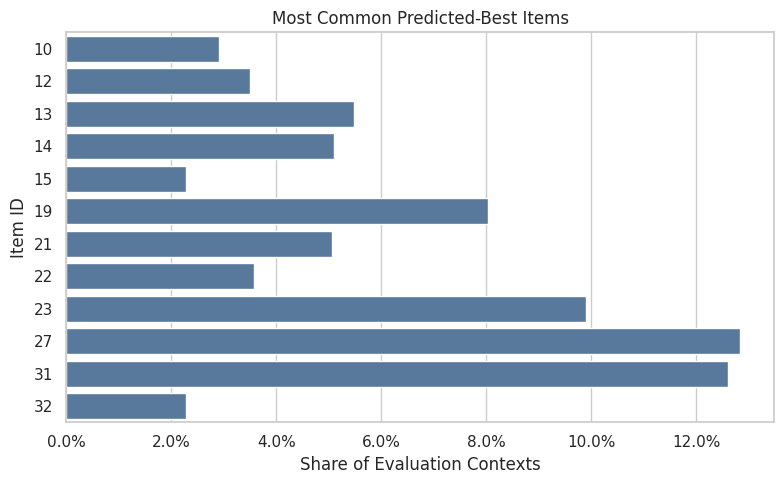

In [11]:
top_best_items = best_item_distribution.head(12).sort_values("context_share")

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=top_best_items, x="context_share", y="item_id", orient="h", ax=ax, color="#4C78A8")
ax.set_title("Most Common Predicted-Best Items")
ax.set_xlabel("Share of Evaluation Contexts")
ax.set_ylabel("Item ID")
ax.xaxis.set_major_formatter(lambda x, _: f"{x:.1%}")
plt.tight_layout()
plt.show()


The concentration metrics quantify how spread out the logging policy is across actions. Lower entropy or higher concentration means fewer actions dominate the log, increasing support risk. The important comparison is which policy remains credible after support, uncertainty, and operational constraints are considered.


### Fixed Baseline Policies

Before adding contextual policies, we recreate two fixed baselines:

- `uniform`: every item gets equal probability
- `fixed_ctr_weighted`: item probability is proportional to smoothed training CTR

These baselines make the contextual policy comparison grounded. A learned contextual policy should beat or at least improve on these simpler policies after accounting for support and uncertainty.


In [12]:
# Recreate fixed baseline policies.
SMOOTHING_ALPHA = 50
train_global_ctr = train_df["click"].mean()

item_stats = (
    train_df.groupby("item_id")
    .agg(train_impressions=("click", "size"), train_clicks=("click", "sum"), train_ctr=("click", "mean"))
    .reindex(action_space, fill_value=0)
    .rename_axis("item_id")
    .reset_index()
)
item_stats["smoothed_ctr"] = (
    item_stats["train_clicks"] + SMOOTHING_ALPHA * train_global_ctr
) / (item_stats["train_impressions"] + SMOOTHING_ALPHA)

def normalize_probabilities(values):
    """
    Normalize nonnegative scores into action probabilities.
    
    Idea
    ----
    The helper turns item scores into a valid evaluation-policy distribution and protects OPE estimators from zero-sum or invalid probability vectors.
    
    Parameters
    ----------
    values : object
        Numeric values to summarize.
    
    Returns
    -------
    numpy.ndarray
        Probability vector that sums to one.
    """
    values = np.asarray(values, dtype=float)
    values = np.clip(values, 0, None)
    total = values.sum()
    if total <= 0:
        raise ValueError("Policy scores must have positive total mass.")
    return values / total

uniform_probs = np.full(n_actions, 1 / n_actions)
fixed_ctr_probs = normalize_probabilities(item_stats["smoothed_ctr"].to_numpy())

fixed_policy_summary = pd.DataFrame(
    {
        "item_id": action_space,
        "uniform": uniform_probs,
        "fixed_ctr_weighted": fixed_ctr_probs,
        "smoothed_ctr": item_stats["smoothed_ctr"],
    }
)

fixed_policy_summary.sort_values("fixed_ctr_weighted", ascending=False).head(10)


,item_id,uniform,fixed_ctr_weighted,smoothed_ctr
31,31,0.029412,0.080613,0.014926
27,27,0.029412,0.061867,0.011455
23,23,0.029412,0.053500,0.009906
14,14,0.029412,0.045993,0.008516
21,21,0.029412,0.044183,0.008181
0,0,0.029412,0.040498,0.007498
22,22,0.029412,0.040379,0.007476
20,20,0.029412,0.037530,0.006949
12,12,0.029412,0.037085,0.006867
2,2,0.029412,0.036929,0.006838


The policy definitions create several offline candidates with different levels of targeting. Comparing simple policies first makes it easier to understand IPS, SNIPS, and DR behavior before moving to contextual policies.


#### Define Contextual Policy Helpers

This cell converts predicted reward scores into policy probability matrices.

We define several learned policies:

- `lgbm_greedy`: puts all probability on the predicted best item
- `lgbm_epsilon_greedy`: puts most probability on the best item and keeps exploration mass elsewhere
- `lgbm_softmax`: smoothly allocates probability based on predicted reward
- `lgbm_conservative_mix`: mixes the learned softmax policy with uniform exploration

The conservative mix is often the most realistic offline candidate because it benefits from model scores while preserving broad support.


In [13]:
# Define contextual policy helpers.
def softmax_policy(scores, temperature):
    """
    Convert predicted rewards into a softmax policy.
    
    Idea
    ----
    The policy spreads probability across items according to score differences, which creates a smoother alternative to greedy recommendation.
    
    Parameters
    ----------
    scores : object
        Model scores used to define a contextual policy.
    temperature : object
        Softmax temperature controlling policy concentration.
    
    Returns
    -------
    numpy.ndarray
        Row-normalized action-probability matrix.
    """
    centered = scores - scores.max(axis=1, keepdims=True)
    exp_scores = np.exp(centered / temperature)
    return exp_scores / exp_scores.sum(axis=1, keepdims=True)


def epsilon_greedy_policy(scores, epsilon=0.15):
    """
    Convert predicted rewards into an epsilon-greedy policy.
    
    Idea
    ----
    The policy assigns most probability to the best predicted item while retaining exploration probability for other supported actions.
    
    Parameters
    ----------
    scores : object
        Model scores used to define a contextual policy.
    epsilon : object
        Exploration probability for epsilon-greedy policies.
    
    Returns
    -------
    numpy.ndarray
        Row-normalized action-probability matrix.
    """
    policy = np.full(scores.shape, epsilon / scores.shape[1])
    best_idx = scores.argmax(axis=1)
    policy[np.arange(scores.shape[0]), best_idx] += 1 - epsilon
    return policy


def greedy_policy(scores):
    """
    Convert predicted rewards into a deterministic greedy policy.
    
    Idea
    ----
    The policy places all probability on the highest predicted reward action for each context, making support risk visible in OPE diagnostics.
    
    Parameters
    ----------
    scores : object
        Model scores used to define a contextual policy.
    
    Returns
    -------
    numpy.ndarray
        One-hot action-probability matrix.
    """
    policy = np.zeros_like(scores)
    best_idx = scores.argmax(axis=1)
    policy[np.arange(scores.shape[0]), best_idx] = 1.0
    return policy

SOFTMAX_TEMPERATURE = max(float(np.std(q_matrix)), 0.001)
SOFTMAX_TEMPERATURE


0.01352180357280611

These cells define policies that can choose different items for different user contexts. This is the transition from evaluating fixed item-distribution policies to evaluating learned contextual recommendation rules.


### Fixed and Contextual Policy Matrices

Each policy matrix has one row per evaluation context and one column per action. Row `i`, column `a` is `pi_e(a|x_i)`.

Fixed policies repeat the same probability vector for every row. Contextual policies vary by row because they depend on LightGBM predicted rewards for that context.


In [14]:
uniform_matrix = np.tile(uniform_probs, (len(eval_df), 1))
fixed_ctr_matrix = np.tile(fixed_ctr_probs, (len(eval_df), 1))
softmax_matrix = softmax_policy(q_matrix, temperature=SOFTMAX_TEMPERATURE)
epsilon_greedy_matrix = epsilon_greedy_policy(q_matrix, epsilon=0.15)
greedy_matrix = greedy_policy(q_matrix)
conservative_mix_matrix = 0.70 * uniform_matrix + 0.30 * softmax_matrix

policy_matrices = {
    "uniform": uniform_matrix,
    "fixed_ctr_weighted": fixed_ctr_matrix,
    "lgbm_softmax": softmax_matrix,
    "lgbm_epsilon_greedy": epsilon_greedy_matrix,
    "lgbm_greedy": greedy_matrix,
    "lgbm_conservative_mix": conservative_mix_matrix,
}

pd.DataFrame(
    {
        "policy": list(policy_matrices),
        "rows": [matrix.shape[0] for matrix in policy_matrices.values()],
        "actions": [matrix.shape[1] for matrix in policy_matrices.values()],
        "min_row_sum": [matrix.sum(axis=1).min() for matrix in policy_matrices.values()],
        "max_row_sum": [matrix.sum(axis=1).max() for matrix in policy_matrices.values()],
    }
)


,policy,rows,actions,min_row_sum,max_row_sum
0,uniform,100000,34,1.000000,1.000000
1,fixed_ctr_weighted,100000,34,1.000000,1.000000
2,lgbm_softmax,100000,34,1.000000,1.000000
3,lgbm_epsilon_greedy,100000,34,1.000000,1.000000
4,lgbm_greedy,100000,34,1.000000,1.000000
5,lgbm_conservative_mix,100000,34,1.000000,1.000000


These cells define policies that can choose different items for different user contexts. This is the transition from evaluating fixed item-distribution policies to evaluating learned contextual recommendation rules.


#### Audit Contextual Policy Behavior

This cell summarizes how concentrated each policy is.

The most useful fields are:

- `avg_max_action_probability`: how much probability the policy puts on its favorite action in an average context
- `normalized_entropy`: how diffuse or concentrated the policy is
- `avg_logged_action_probability`: how much probability the policy assigns to the action actually logged by the behavior policy

Aggressive policies tend to have high max probability and low entropy. Conservative policies preserve more exploration.


In [15]:
# Audit contextual policy behavior.
def normalized_entropy(policy_matrix):
    """
    Compute normalized entropy for policy or action shares.
    
    Idea
    ----
    Entropy summarizes how concentrated a policy is across items, which helps identify greedy or low-diversity policies that may have weak support.
    
    Parameters
    ----------
    policy_matrix : object
        Matrix of action probabilities for each context.
    
    Returns
    -------
    float
        Entropy scaled to the interval from zero to one.
    """
    safe = np.clip(policy_matrix, 1e-15, 1)
    entropy = -(safe * np.log(safe)).sum(axis=1)
    return entropy / np.log(policy_matrix.shape[1])

logged_action_indices = eval_df["item_id"].map(action_to_index).to_numpy()
policy_audit_rows = []

for policy_name, matrix in policy_matrices.items():
    logged_probs = matrix[np.arange(len(eval_df)), logged_action_indices]
    policy_audit_rows.append(
        {
            "policy": policy_name,
            "min_row_sum": matrix.sum(axis=1).min(),
            "max_row_sum": matrix.sum(axis=1).max(),
            "avg_max_action_probability": matrix.max(axis=1).mean(),
            "p95_max_action_probability": np.percentile(matrix.max(axis=1), 95),
            "avg_normalized_entropy": normalized_entropy(matrix).mean(),
            "avg_logged_action_probability": logged_probs.mean(),
            "share_logged_action_probability_zero": (logged_probs == 0).mean(),
        }
    )

policy_audit = pd.DataFrame(policy_audit_rows).sort_values("avg_normalized_entropy")
policy_audit


,policy,min_row_sum,max_row_sum,avg_max_action_probability,p95_max_action_probability,avg_normalized_entropy,avg_logged_action_probability,share_logged_action_probability_zero
4,lgbm_greedy,1.000000,1.000000,1.000000,1.000000,0.000000,0.029100,0.970900
3,lgbm_epsilon_greedy,1.000000,1.000000,0.854412,0.854412,0.262035,0.029147,0.000000
2,lgbm_softmax,1.000000,1.000000,0.237347,0.999768,0.828504,0.029277,0.000000
1,fixed_ctr_weighted,1.000000,1.000000,0.080613,0.080613,0.965997,0.029323,0.000000
5,lgbm_conservative_mix,1.000000,1.000000,0.091792,0.320519,0.974767,0.029371,0.000000
0,uniform,1.000000,1.000000,0.029412,0.029412,1.000000,0.029412,0.000000


The contextual policy audit summarizes entropy, top-action concentration, and support properties. These diagnostics help separate a promising contextual policy from one that is too aggressive for reliable offline evaluation.


#### Plot Policy Concentration

This plot compares average maximum action probability with normalized entropy.

Policies in the upper-left area are aggressive: they put high probability on one action and have low entropy. Policies toward the lower-right are more exploratory. For offline OPE, very aggressive policies often have lower effective sample size.


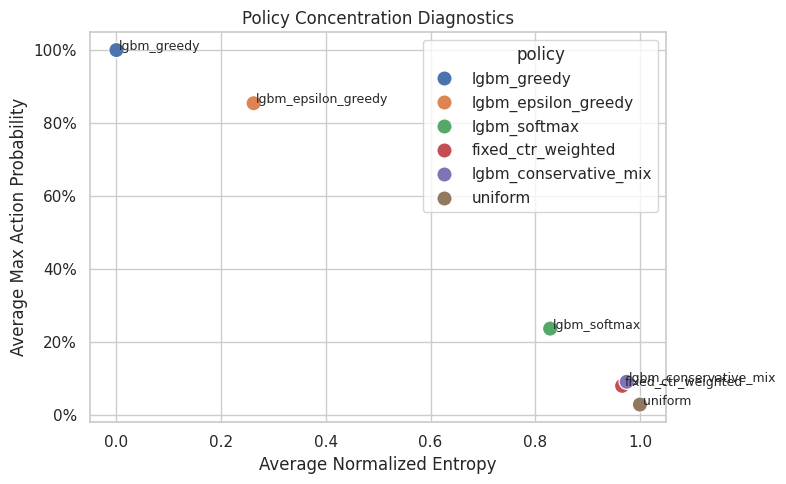

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(
    data=policy_audit,
    x="avg_normalized_entropy",
    y="avg_max_action_probability",
    hue="policy",
    s=120,
    ax=ax,
)
for _, row in policy_audit.iterrows():
    ax.text(row["avg_normalized_entropy"] + 0.005, row["avg_max_action_probability"], row["policy"], fontsize=9)
ax.set_title("Policy Concentration Diagnostics")
ax.set_xlabel("Average Normalized Entropy")
ax.set_ylabel("Average Max Action Probability")
ax.yaxis.set_major_formatter(lambda y, _: f"{y:.0%}")
plt.tight_layout()
plt.show()


The concentration metrics quantify how spread out the logging policy is across actions. Lower entropy or higher concentration means fewer actions dominate the log, increasing support risk. In OPE, this diagnostic determines whether a target policy is being evaluated from real logged support or from a few high-leverage coincidences.


#### Define OPE Estimator Helpers

This cell defines IPS, SNIPS, direct method, and doubly robust estimators for contextual policies.

For contextual policies, `pi_e(A_i|X_i)` comes from the policy matrix row for context `i` and the logged action column. The direct component is `sum_a pi_e(a|x_i) q_hat(x_i, a)`.


In [17]:
# Define OPE estimator helpers.
def effective_sample_size(weights):
    """
    Compute the effective sample size implied by importance weights.
    
    Idea
    ----
    Large or unstable weights can make an estimator behave as if it had far fewer observations; this diagnostic turns weight concentration into a readable sample-size number.
    
    Parameters
    ----------
    weights : object
        Observation weights aligned with the values.
    
    Returns
    -------
    float
        Effective sample size computed as squared total weight divided by total squared weight.
    """
    weights = np.asarray(weights, dtype=float)
    return weights.sum() ** 2 / np.square(weights).sum()


def summarize_signal(signal):
    """
    Summarize the distribution of an OPE diagnostic signal.
    
    Idea
    ----
    The helper reports quantiles and extremes for weights, propensities, or residual terms so unstable policies are easy to spot.
    
    Parameters
    ----------
    signal : object
        Diagnostic vector to summarize.
    
    Returns
    -------
    dict
        Summary statistics for the supplied diagnostic vector.
    """
    signal = np.asarray(signal, dtype=float)
    estimate = signal.mean()
    se = signal.std(ddof=1) / np.sqrt(len(signal))
    return estimate, se, estimate - 1.96 * se, estimate + 1.96 * se


def estimate_contextual_policy(policy_name, policy_matrix, clip=None):
    """
    Evaluate one contextual policy with OPE diagnostics.
    
    Idea
    ----
    The function extracts the logged-action probability under the candidate policy, forms importance weights, and reports value estimates plus support risk.
    
    Parameters
    ----------
    policy_name : object
        Name of the candidate policy being evaluated.
    policy_matrix : object
        Matrix of action probabilities for each context.
    clip : object
        Optional upper bound for importance weights.
    
    Returns
    -------
    pandas.DataFrame
        Estimator table for the contextual policy and clipping setting.
    """
    reward = eval_df["click"].to_numpy(dtype=float)
    behavior_propensity = eval_df["propensity_score"].to_numpy(dtype=float)
    pi_logged = policy_matrix[np.arange(len(eval_df)), logged_action_indices]
    raw_weight = pi_logged / behavior_propensity
    weight = raw_weight if clip is None else np.minimum(raw_weight, clip)

    direct_component = (policy_matrix * q_matrix).sum(axis=1)
    correction = weight * (reward - q_logged)
    dr_signal = direct_component + correction

    ips_signal = weight * reward
    ips = summarize_signal(ips_signal)

    snips_estimate = ips_signal.sum() / weight.sum()
    snips_influence = weight * (reward - snips_estimate) / weight.mean()
    snips_se = snips_influence.std(ddof=1) / np.sqrt(len(snips_influence))
    snips = (snips_estimate, snips_se, snips_estimate - 1.96 * snips_se, snips_estimate + 1.96 * snips_se)

    dm = summarize_signal(direct_component)
    dr = summarize_signal(dr_signal)

    rows = []
    for estimator_name, values in [("IPS", ips), ("SNIPS", snips), ("DM", dm), ("DR", dr)]:
        estimate, se, lower, upper = values
        rows.append(
            {
                "policy": policy_name,
                "estimator": estimator_name,
                "clip": "none" if clip is None else clip,
                "estimate": estimate,
                "se": se,
                "ci_95_lower": lower,
                "ci_95_upper": upper,
                "mean_weight": weight.mean(),
                "max_weight": weight.max(),
                "p99_weight": np.percentile(weight, 99),
                "ess_share": effective_sample_size(weight) / len(weight),
                "mean_abs_correction": np.abs(correction).mean(),
                "mean_correction": correction.mean(),
                "avg_direct_component": direct_component.mean(),
                "observed_random_click_rate": eval_df["click"].mean(),
            }
        )
    return pd.DataFrame(rows)


The helper functions encode the estimator formulas and diagnostics used repeatedly in the notebook. Defining them once keeps the later policy comparisons consistent and easier to audit. Poor overlap or extreme propensity scores would make the adjusted estimate depend on a narrow slice of comparable observations.


### Estimate Fixed and Contextual Policy Values

This cell estimates each policy with IPS, SNIPS, direct method, and doubly robust OPE.

The preferred comparison for learned contextual policies is the DR estimate plus support diagnostics. Direct method can overtrust the model, while IPS/SNIPS can become noisy for aggressive policies.


In [18]:
policy_estimate_frames = []
for policy_name, policy_matrix in policy_matrices.items():
    policy_estimate_frames.append(estimate_contextual_policy(policy_name, policy_matrix, clip=None))

contextual_estimates = pd.concat(policy_estimate_frames, ignore_index=True)
contextual_estimates["lift_pp"] = 100 * (
    contextual_estimates["estimate"] - contextual_estimates["observed_random_click_rate"]
)
contextual_estimates["relative_lift_pct"] = 100 * (
    contextual_estimates["estimate"] / contextual_estimates["observed_random_click_rate"] - 1
)

contextual_estimates.sort_values(["estimator", "estimate"], ascending=[True, False])


,policy,estimator,clip,estimate,se,ci_95_lower,ci_95_upper,mean_weight,max_weight,p99_weight,ess_share,mean_abs_correction,mean_correction,avg_direct_component,observed_random_click_rate,lift_pp,relative_lift_pct
18,lgbm_greedy,DM,none,0.039434,0.000194,0.039053,0.039815,0.989400,34.000000,34.000000,0.029100,0.043579,-0.031920,0.039434,0.004980,3.445377,691.842735
14,lgbm_epsilon_greedy,DM,none,0.034253,0.000167,0.033926,0.034580,0.990990,29.050000,29.050000,0.039955,0.038508,-0.027112,0.034253,0.004980,2.927343,587.819794
10,lgbm_softmax,DM,none,0.028713,0.000201,0.028319,0.029106,0.995411,34.000000,5.113957,0.168632,0.032162,-0.022712,0.028713,0.004980,2.373265,476.559177
22,lgbm_conservative_mix,DM,none,0.012043,0.000068,0.011909,0.012176,0.998623,10.900000,2.234187,0.694032,0.016486,-0.006718,0.012043,0.004980,0.706250,141.817278
6,fixed_ctr_weighted,DM,none,0.005973,0.000017,0.005940,0.006005,0.996987,2.740842,2.740842,0.790628,0.010967,-0.000691,0.005973,0.004980,0.099258,19.931326
2,uniform,DM,none,0.004898,0.000013,0.004872,0.004924,1.000000,1.000000,1.000000,1.000000,0.009768,0.000136,0.004898,0.004980,-0.008185,-1.643536
19,lgbm_greedy,DR,none,0.007513,0.001866,0.003857,0.011170,0.989400,34.000000,34.000000,0.029100,0.043579,-0.031920,0.039434,0.004980,0.253344,50.872251
15,lgbm_epsilon_greedy,DR,none,0.007142,0.001594,0.004016,0.010267,0.990990,29.050000,29.050000,0.039955,0.038508,-0.027112,0.034253,0.004980,0.216160,43.405703
11,lgbm_softmax,DR,none,0.006001,0.001267,0.003518,0.008484,0.995411,34.000000,5.113957,0.168632,0.032162,-0.022712,0.028713,0.004980,0.102106,20.503156
23,lgbm_conservative_mix,DR,none,0.005324,0.000454,0.004434,0.006215,0.998623,10.900000,2.234187,0.694032,0.016486,-0.006718,0.012043,0.004980,0.034450,6.917631


The contextual OPE estimates compare learned policies against fixed baselines. The key question is whether personalization improves estimated value without creating unacceptable weight or support risk. The teaching point is that weighting can reduce bias while also reducing usable information, so stability matters as much as the point estimate.


#### Plot OPE Estimates For Learned Policies

This plot compares IPS, SNIPS, and DR estimates. Direct method is omitted to keep the visual focused on estimators that incorporate logged outcomes through propensities or residual correction.

The key pattern to look for is whether contextual policies improve estimated value while keeping uncertainty and support acceptable.


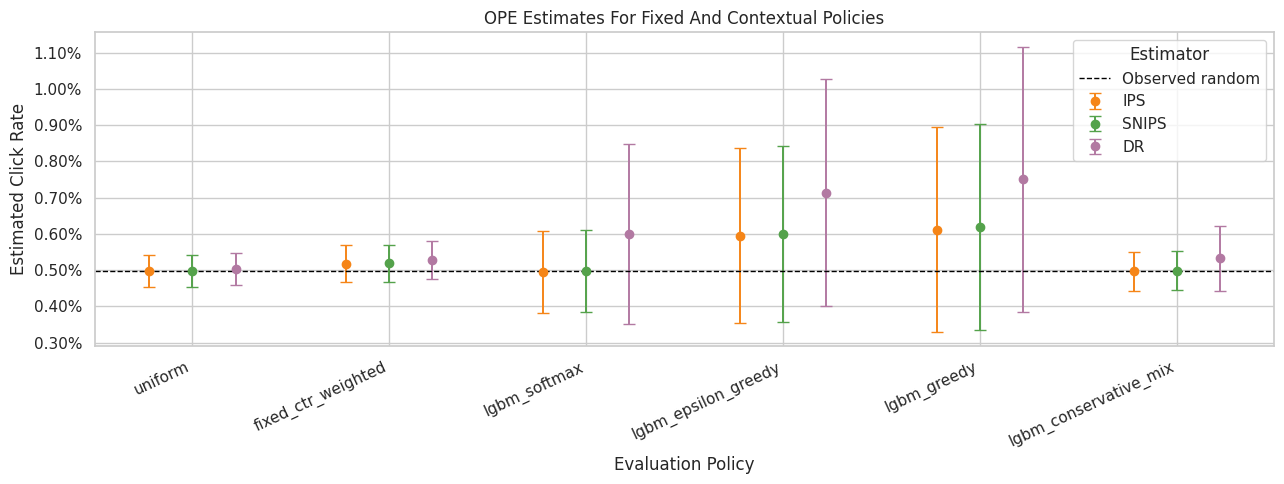

In [19]:
# Plot OPE estimates for learned policies.
plot_estimates = contextual_estimates.query("estimator in ['IPS', 'SNIPS', 'DR']").copy()
plot_estimates["lower_error"] = plot_estimates["estimate"] - plot_estimates["ci_95_lower"]
plot_estimates["upper_error"] = plot_estimates["ci_95_upper"] - plot_estimates["estimate"]

policy_order = plot_estimates["policy"].drop_duplicates().tolist()
estimator_order = ["IPS", "SNIPS", "DR"]
offsets = {"IPS": -0.22, "SNIPS": 0.0, "DR": 0.22}
colors = {"IPS": "#F58518", "SNIPS": "#54A24B", "DR": "#B279A2"}

fig, ax = plt.subplots(figsize=(13, 5))
for estimator in estimator_order:
    subset = plot_estimates[plot_estimates["estimator"] == estimator]
    for _, row in subset.iterrows():
        x_base = policy_order.index(row["policy"])
        x = x_base + offsets[estimator]
        ax.errorbar(
            x=x,
            y=row["estimate"],
            yerr=[[row["lower_error"]], [row["upper_error"]]],
            fmt="o",
            color=colors[estimator],
            ecolor=colors[estimator],
            capsize=4,
            linewidth=1.4,
            markersize=6,
            label=estimator if row["policy"] == subset["policy"].iloc[0] else None,
        )

ax.axhline(eval_df["click"].mean(), color="black", linestyle="--", linewidth=1, label="Observed random")
ax.set_xticks(range(len(policy_order)))
ax.set_xticklabels(policy_order, rotation=25, ha="right")
ax.set_title("OPE Estimates For Fixed And Contextual Policies")
ax.set_xlabel("Evaluation Policy")
ax.set_ylabel("Estimated Click Rate")
ax.yaxis.set_major_formatter(lambda y, _: f"{y:.2%}")
ax.legend(title="Estimator")
plt.tight_layout()
plt.show()


The estimate plot compares policies on the same offline value scale. Error bars and estimator differences are just as important as the ranking, because high-variance estimates need guardrails before product decisions.


### Weight and Support Diagnostics

This table focuses on the importance weights for each policy.

The most aggressive policies may have high estimated value but low effective sample size. For a realistic offline recommendation, we should prefer policies with both good value and defensible support.


In [20]:
weight_diagnostics = (
    contextual_estimates.query("estimator == 'DR'")
    [["policy", "mean_weight", "max_weight", "p99_weight", "ess_share", "mean_abs_correction", "mean_correction"]]
    .merge(policy_audit, on="policy", how="left")
    .sort_values("ess_share")
)

weight_diagnostics


,policy,mean_weight,max_weight,p99_weight,ess_share,mean_abs_correction,mean_correction,min_row_sum,max_row_sum,avg_max_action_probability,p95_max_action_probability,avg_normalized_entropy,avg_logged_action_probability,share_logged_action_probability_zero
4,lgbm_greedy,0.989400,34.000000,34.000000,0.029100,0.043579,-0.031920,1.000000,1.000000,1.000000,1.000000,0.000000,0.029100,0.970900
3,lgbm_epsilon_greedy,0.990990,29.050000,29.050000,0.039955,0.038508,-0.027112,1.000000,1.000000,0.854412,0.854412,0.262035,0.029147,0.000000
2,lgbm_softmax,0.995411,34.000000,5.113957,0.168632,0.032162,-0.022712,1.000000,1.000000,0.237347,0.999768,0.828504,0.029277,0.000000
5,lgbm_conservative_mix,0.998623,10.900000,2.234187,0.694032,0.016486,-0.006718,1.000000,1.000000,0.091792,0.320519,0.974767,0.029371,0.000000
1,fixed_ctr_weighted,0.996987,2.740842,2.740842,0.790628,0.010967,-0.000691,1.000000,1.000000,0.080613,0.080613,0.965997,0.029323,0.000000
0,uniform,1.000000,1.000000,1.000000,1.000000,0.009768,0.000136,1.000000,1.000000,0.029412,0.029412,1.000000,0.029412,0.000000


This output is part of the contextual policy learning with offline evaluation workflow. Read it as a checkpoint that either verifies the log, defines reusable estimator machinery, or produces a diagnostic that motivates the next OPE step.


#### Plot Weight Risk And Effective Sample Size

This plot separates two ideas:

- the largest and tail weights, which flag variance risk
- effective sample size, which summarizes how much useful support remains after weighting

This makes the tradeoff clear: aggressive contextual policies may improve predicted value, but they often pay for it with weaker support.


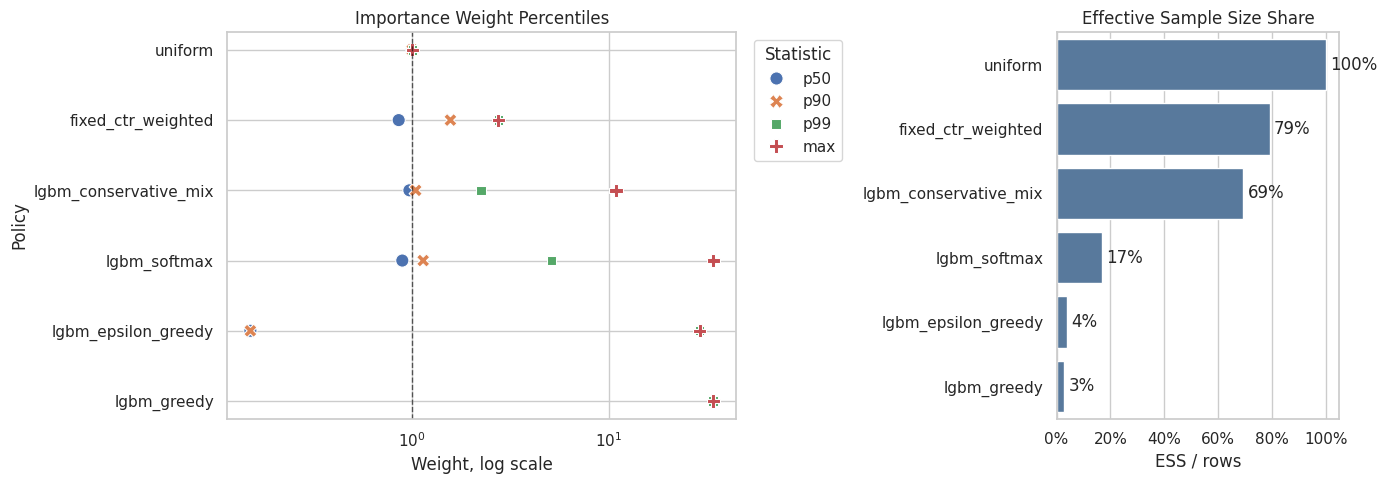

,policy,p50,p90,p99,max,ess_share
0,uniform,1.000000,1.000000,1.000000,1.000000,1.000000
1,fixed_ctr_weighted,0.852995,1.563756,2.740842,2.740842,0.790628
5,lgbm_conservative_mix,0.966942,1.040916,2.234187,10.900000,0.694032
2,lgbm_softmax,0.889807,1.136388,5.113957,34.000000,0.168632
3,lgbm_epsilon_greedy,0.150000,0.150000,29.050000,29.050000,0.039955
4,lgbm_greedy,0.000000,0.000000,34.000000,34.000000,0.029100


In [21]:
# Plot weight risk and effective sample size.
weight_plot_rows = []
for policy_name, policy_matrix in policy_matrices.items():
    pi_logged = policy_matrix[np.arange(len(eval_df)), logged_action_indices]
    weights = pi_logged / eval_df["propensity_score"].to_numpy()
    weight_plot_rows.append(
        {
            "policy": policy_name,
            "p50": np.percentile(weights, 50),
            "p90": np.percentile(weights, 90),
            "p99": np.percentile(weights, 99),
            "max": weights.max(),
            "ess_share": effective_sample_size(weights) / len(weights),
        }
    )

weight_plot_summary = pd.DataFrame(weight_plot_rows).sort_values("ess_share", ascending=False)
weight_percentile_plot = weight_plot_summary.melt(
    id_vars="policy",
    value_vars=["p50", "p90", "p99", "max"],
    var_name="statistic",
    value_name="weight",
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={"width_ratios": [1.8, 1]})

sns.scatterplot(
    data=weight_percentile_plot,
    x="weight",
    y="policy",
    hue="statistic",
    style="statistic",
    s=90,
    ax=axes[0],
)
axes[0].set_xscale("log")
axes[0].set_title("Importance Weight Percentiles")
axes[0].set_xlabel("Weight, log scale")
axes[0].set_ylabel("Policy")
axes[0].axvline(1, color="black", linestyle="--", linewidth=1, alpha=0.6)
axes[0].legend(title="Statistic", bbox_to_anchor=(1.02, 1), loc="upper left")

sns.barplot(data=weight_plot_summary, x="ess_share", y="policy", color="#4C78A8", ax=axes[1])
axes[1].set_title("Effective Sample Size Share")
axes[1].set_xlabel("ESS / rows")
axes[1].set_ylabel("")
axes[1].set_xlim(0, 1.05)
axes[1].xaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
for container in axes[1].containers:
    axes[1].bar_label(container, fmt=lambda x: f"{x:.0%}", padding=3)

plt.tight_layout()
plt.show()

weight_plot_summary


Effective sample size turns weight concentration into an intuitive sample-size diagnostic. A low ESS means the estimator has less usable information than the raw row count suggests.


### Weight Clipping Sensitivity for Contextual Policies

This section checks whether learned policy estimates depend on extreme weights.

We compare no clipping with caps at 5, 10, and 20. A policy whose DR estimate changes sharply under clipping is less stable. A policy whose DR estimate stays similar is more credible for offline recommendation.


In [22]:
clip_values = [None, 5, 10, 20]
clipping_frames = []

for clip in clip_values:
    for policy_name, policy_matrix in policy_matrices.items():
        clipping_frames.append(estimate_contextual_policy(policy_name, policy_matrix, clip=clip))

clipping_sensitivity = pd.concat(clipping_frames, ignore_index=True)
clipping_sensitivity["lift_pp"] = 100 * (
    clipping_sensitivity["estimate"] - clipping_sensitivity["observed_random_click_rate"]
)

clipping_sensitivity.query("estimator == 'DR'").head(12)


,policy,estimator,clip,estimate,se,ci_95_lower,ci_95_upper,mean_weight,max_weight,p99_weight,ess_share,mean_abs_correction,mean_correction,avg_direct_component,observed_random_click_rate,lift_pp
3,uniform,DR,none,0.005035,0.000226,0.004592,0.005477,1.000000,1.000000,1.000000,1.000000,0.009768,0.000136,0.004898,0.004980,0.005454
7,fixed_ctr_weighted,DR,none,0.005281,0.000268,0.004757,0.005806,0.996987,2.740842,2.740842,0.790628,0.010967,-0.000691,0.005973,0.004980,0.030119
11,lgbm_softmax,DR,none,0.006001,0.001267,0.003518,0.008484,0.995411,34.000000,5.113957,0.168632,0.032162,-0.022712,0.028713,0.004980,0.102106
15,lgbm_epsilon_greedy,DR,none,0.007142,0.001594,0.004016,0.010267,0.990990,29.050000,29.050000,0.039955,0.038508,-0.027112,0.034253,0.004980,0.216160
19,lgbm_greedy,DR,none,0.007513,0.001866,0.003857,0.011170,0.989400,34.000000,34.000000,0.029100,0.043579,-0.031920,0.039434,0.004980,0.253344
23,lgbm_conservative_mix,DR,none,0.005324,0.000454,0.004434,0.006215,0.998623,10.900000,2.234187,0.694032,0.016486,-0.006718,0.012043,0.004980,0.034450
27,uniform,DR,5,0.005035,0.000226,0.004592,0.005477,1.000000,1.000000,1.000000,1.000000,0.009768,0.000136,0.004898,0.004980,0.005454
31,fixed_ctr_weighted,DR,5,0.005281,0.000268,0.004757,0.005806,0.996987,2.740842,2.740842,0.790628,0.010967,-0.000691,0.005973,0.004980,0.030119
35,lgbm_softmax,DR,5,0.024611,0.000343,0.023938,0.025284,0.851704,5.000000,5.000000,0.650776,0.012142,-0.004102,0.028713,0.004980,1.963055
39,lgbm_epsilon_greedy,DR,5,0.029721,0.000311,0.029112,0.030329,0.291135,5.000000,5.000000,0.113112,0.007682,-0.004533,0.034253,0.004980,2.474054


The clipping sensitivity check shows how estimates change when extreme weights are capped. Stable estimates across clipping thresholds are more reassuring than estimates that depend strongly on a few high-weight rows.


#### Plot DR Clipping Sensitivity

This plot shows how DR estimates move as weights are clipped.

Greedy and epsilon-greedy policies are expected to be more sensitive because they concentrate probability on fewer actions. The conservative mix should be more stable because it keeps substantial uniform exploration mass.


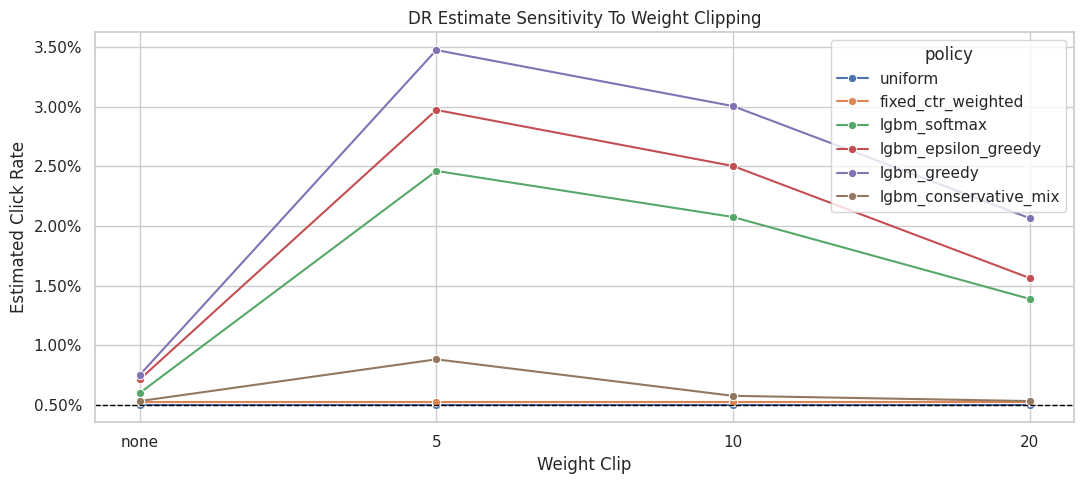

In [23]:
dr_clipping_plot = clipping_sensitivity.query("estimator == 'DR'").copy()
dr_clipping_plot["clip_label"] = dr_clipping_plot["clip"].astype(str)

fig, ax = plt.subplots(figsize=(11, 5))
sns.lineplot(
    data=dr_clipping_plot,
    x="clip_label",
    y="estimate",
    hue="policy",
    marker="o",
    ax=ax,
)
ax.axhline(eval_df["click"].mean(), color="black", linestyle="--", linewidth=1, label="Observed random")
ax.set_title("DR Estimate Sensitivity To Weight Clipping")
ax.set_xlabel("Weight Clip")
ax.set_ylabel("Estimated Click Rate")
ax.yaxis.set_major_formatter(lambda y, _: f"{y:.2%}")
plt.tight_layout()
plt.show()


The clipping sensitivity check shows how estimates change when extreme weights are capped. Stable estimates across clipping thresholds are more reassuring than estimates that depend strongly on a few high-weight rows.


#### Clipping Stability Summary

This cell summarizes how much each policy's DR estimate changes across clipping thresholds.

A smaller estimate range means the policy estimate is less dependent on extreme weights. This is useful when deciding whether an aggressive learned policy is too risky for offline recommendation.


In [24]:
clipping_stability = (
    clipping_sensitivity.query("estimator == 'DR'")
    .groupby("policy")
    .agg(
        min_dr_estimate=("estimate", "min"),
        max_dr_estimate=("estimate", "max"),
        dr_estimate_range=("estimate", lambda x: x.max() - x.min()),
        min_ess_share=("ess_share", "min"),
        max_weight=("max_weight", "max"),
    )
    .reset_index()
    .sort_values("dr_estimate_range", ascending=False)
)

clipping_stability


,policy,min_dr_estimate,max_dr_estimate,dr_estimate_range,min_ess_share,max_weight
3,lgbm_greedy,0.007513,0.034740,0.027226,0.029100,34.000000
2,lgbm_epsilon_greedy,0.007142,0.029721,0.022579,0.039955,29.050000
4,lgbm_softmax,0.006001,0.024611,0.018609,0.168632,34.000000
1,lgbm_conservative_mix,0.005324,0.008822,0.003497,0.694032,10.900000
0,fixed_ctr_weighted,0.005281,0.005281,0.000000,0.790628,2.740842
5,uniform,0.005035,0.005035,0.000000,1.000000,1.000000


The clipping sensitivity check shows how estimates change when extreme weights are capped. Stable estimates across clipping thresholds are more reassuring than estimates that depend strongly on a few high-weight rows.


#### Conservative Policy Improvement Table

This table creates a support-adjusted score for policy selection.

The score is:

`support_adjusted_lift_pp = DR lift in percentage points * sqrt(ESS share)`

This score is a decision aid that penalizes weak effective sample size. It is a decision aid that penalizes policies with weak effective sample size. It helps prevent the notebook from recommending a policy only because it has an aggressive point estimate.


In [25]:
# Conservative policy improvement table.
dr_results = contextual_estimates.query("estimator == 'DR'").copy()
dr_results = dr_results.merge(
    clipping_stability[["policy", "dr_estimate_range"]], on="policy", how="left"
)
dr_results["support_adjusted_lift_pp"] = dr_results["lift_pp"] * np.sqrt(dr_results["ess_share"])
dr_results["risk_flag"] = np.select(
    [
        dr_results["ess_share"] < 0.10,
        dr_results["dr_estimate_range"] > 0.001,
        dr_results["max_weight"] > 20,
    ],
    ["low ESS", "clip sensitive", "large max weight"],
    default="reasonable support",
)

policy_decision_table = dr_results[
    [
        "policy",
        "estimate",
        "ci_95_lower",
        "ci_95_upper",
        "lift_pp",
        "relative_lift_pct",
        "ess_share",
        "max_weight",
        "p99_weight",
        "dr_estimate_range",
        "support_adjusted_lift_pp",
        "risk_flag",
    ]
].sort_values("support_adjusted_lift_pp", ascending=False)

policy_decision_table


,policy,estimate,ci_95_lower,ci_95_upper,lift_pp,relative_lift_pct,ess_share,max_weight,p99_weight,dr_estimate_range,support_adjusted_lift_pp,risk_flag
4,lgbm_greedy,0.007513,0.003857,0.011170,0.253344,50.872251,0.029100,34.000000,34.000000,0.027226,0.043217,low ESS
3,lgbm_epsilon_greedy,0.007142,0.004016,0.010267,0.216160,43.405703,0.039955,29.050000,29.050000,0.022579,0.043208,low ESS
2,lgbm_softmax,0.006001,0.003518,0.008484,0.102106,20.503156,0.168632,34.000000,5.113957,0.018609,0.041930,clip sensitive
5,lgbm_conservative_mix,0.005324,0.004434,0.006215,0.034450,6.917631,0.694032,10.900000,2.234187,0.003497,0.028700,clip sensitive
1,fixed_ctr_weighted,0.005281,0.004757,0.005806,0.030119,6.048007,0.790628,2.740842,2.740842,0.000000,0.026781,reasonable support
0,uniform,0.005035,0.004592,0.005477,0.005454,1.095263,1.000000,1.000000,1.000000,0.000000,0.005454,reasonable support


The conservative improvement table discounts aggressive policies by risk diagnostics. This produces a more deployment-minded ranking than simply sorting by the largest estimated value. The teaching point is that weighting can reduce bias while also reducing usable information, so stability matters as much as the point estimate.


## Recommended Contextual Candidate

This cell selects the policy with the highest support-adjusted lift.

The purpose is to make a realistic offline recommendation. The claim is that this policy is a candidate for online testing. We are saying it has the best balance of estimated value and support among the candidates tested here.


In [26]:
recommended_contextual_policy = policy_decision_table.iloc[0]

recommendation_summary = pd.Series(
    {
        "recommended_policy_for_ab_test": recommended_contextual_policy["policy"],
        "dr_estimated_click_rate": recommended_contextual_policy["estimate"],
        "lift_pp_vs_random_behavior": recommended_contextual_policy["lift_pp"],
        "relative_lift_pct_vs_random_behavior": recommended_contextual_policy["relative_lift_pct"],
        "ess_share": recommended_contextual_policy["ess_share"],
        "max_weight": recommended_contextual_policy["max_weight"],
        "support_adjusted_lift_pp": recommended_contextual_policy["support_adjusted_lift_pp"],
        "risk_flag": recommended_contextual_policy["risk_flag"],
    }
).to_frame("value")

recommendation_summary


,value
recommended_policy_for_ab_test,lgbm_greedy
dr_estimated_click_rate,0.007513
lift_pp_vs_random_behavior,0.253344
relative_lift_pct_vs_random_behavior,50.872251
ess_share,0.029100
max_weight,34.000000
support_adjusted_lift_pp,0.043217
risk_flag,low ESS


The recommended candidate is selected from offline evidence that combines value, support risk, uncertainty, and robustness. The decision should balance estimated improvement against support risk, uncertainty, and robustness. The teaching point is that weighting can reduce bias while also reducing usable information, so stability matters as much as the point estimate.


## Plain-English Interpretation

This cell writes a short explanation of the advanced policy-learning result.

The wording is intentionally careful. Offline OPE can identify a good candidate for online testing, but it cannot replace an A/B test. The recommendation should be framed as a next experiment, with production decisions reserved for live testing.


In [27]:
interpretation = f"""
Advanced policy-learning result

The strongest offline candidate by support-adjusted DR lift is: {recommended_contextual_policy['policy']}.

Why this policy is a reasonable A/B-test candidate:
- It uses context-aware LightGBM reward predictions with user, item, and context features.
- It is evaluated with doubly robust OPE and direct model predictions.
- Its support diagnostics are included in the recommendation, so the decision is not based on point estimate alone.
- It is compared against fixed baselines and more aggressive learned policies.

What we should not claim:
- This offline result prioritizes a production test candidate.
- Long-term satisfaction, retention, creator/item ecosystem effects, and novelty fatigue remain outside this estimate.
- Aggressive learned policies may still be risky if support is weak, even when predicted reward looks high.

Recommended next step:
Take the selected contextual policy, or an even more conservative mix of it with the random policy, into an online A/B test with guardrail metrics.
""".strip()

print(interpretation)


Advanced policy-learning result

The strongest offline candidate by support-adjusted DR lift is: lgbm_greedy.

Why this policy is a reasonable A/B-test candidate:
- It uses context-aware LightGBM reward predictions with user, item, and context features.
- It is evaluated with doubly robust OPE and direct model predictions.
- Its support diagnostics are included in the recommendation, so the decision is not based on point estimate alone.
- It is compared against fixed baselines and more aggressive learned policies.

What we should not claim:
- This offline result prioritizes a production test candidate.
- Long-term satisfaction, retention, creator/item ecosystem effects, and novelty fatigue remain outside this estimate.
- Aggressive learned policies may still be risky if support is weak, even when predicted reward looks high.

Recommended next step:
Take the selected contextual policy, or an even more conservative mix of it with the random policy, into an online A/B test with guardrail 

This text cell states the boundary of the offline evidence. Offline evaluation can recommend candidates for online testing, but it cannot replace an A/B test when business-critical deployment decisions are at stake.


## Takeaways and Next Step

This notebook moved the work from evaluating fixed item-probability policies to learning context-aware policies.

The key lessons are:

- Contextual reward models can score every candidate item for every context.
- Greedy learned policies may look attractive but often create support risk.
- Conservative contextual policies can balance personalization with stable OPE diagnostics.
- Doubly robust OPE is the right estimator family for these learned policies because it combines model predictions with logged residual corrections.
- The best offline recommendation is the policy that combines value and stability.

At this point, the off-policy evaluation work has a complete technical arc. The evidence is ready to support a concise project summary about which policy is most justified for online validation and which risks remain unresolved.
